In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('data_1.csv')
data.head()

,Date Time,CO2 (ppm),Temperature (C),Humidity (%)
0,11/3/23 18:45,958,28.24,25.11
1,11/3/23 18:46,939,27.83,25.63
2,11/3/23 18:47,928,27.53,26.00
3,11/3/23 18:48,927,27.34,26.38
4,11/3/23 18:49,928,27.08,26.77


In [3]:
data.value_counts()

Date Time      CO2 (ppm)  Temperature (C)  Humidity (%)
11/3/23 18:45  958        28.24            25.11           1
11/4/23 06:02  960        23.86            63.32           1
11/4/23 05:49  962        23.86            60.77           1
11/4/23 05:50  962        23.86            60.78           1
11/4/23 05:51  962        23.86            60.82           1
                                                          ..
11/4/23 00:25  734        22.92            53.62           1
11/4/23 00:26  734        22.92            53.70           1
11/4/23 00:27  736        22.92            53.99           1
11/4/23 00:28  738        22.92            54.28           1
11/4/23 11:32  901        24.37            57.98           1
Name: count, Length: 1008, dtype: int64

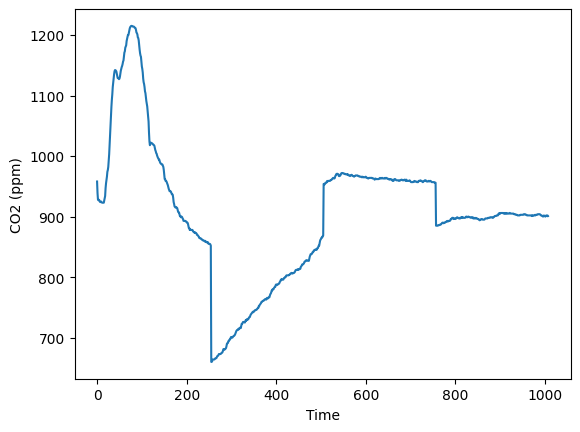

In [4]:
plt.plot(data["CO2 (ppm)"])
plt.xlabel("Time")
plt.ylabel("CO2 (ppm)")
plt.show()

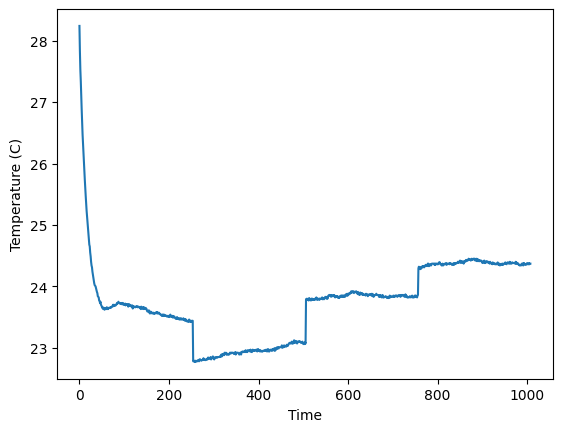

In [5]:
plt.plot(data["Temperature (C)"])
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.show()

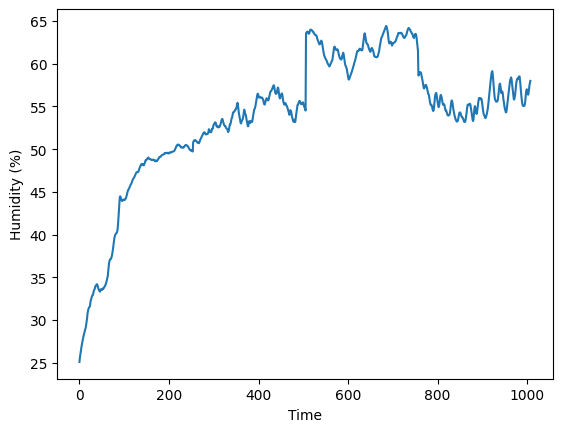

In [6]:
plt.plot(data["Humidity (%)"])
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.show()

In [7]:
### Normalization ###
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
new_data = data.drop(columns=["Date Time"])
data_scaled = scaler.fit_transform(new_data)
data_scaled = pd.DataFrame(data_scaled, columns=new_data.columns)
data_scaled.head()

,CO2 (ppm),Temperature (C),Humidity (%)
0,0.536937,1.000000,0.000000
1,0.502703,0.925046,0.013232
2,0.482883,0.870201,0.022646
3,0.481081,0.835466,0.032316
4,0.482883,0.787934,0.042239


In [8]:
X = data_scaled["Humidity (%)"].values
X.shape

(1008,)

In [9]:
## without normalization ##
# X = data["Humidity (%)"].values
# X.shape

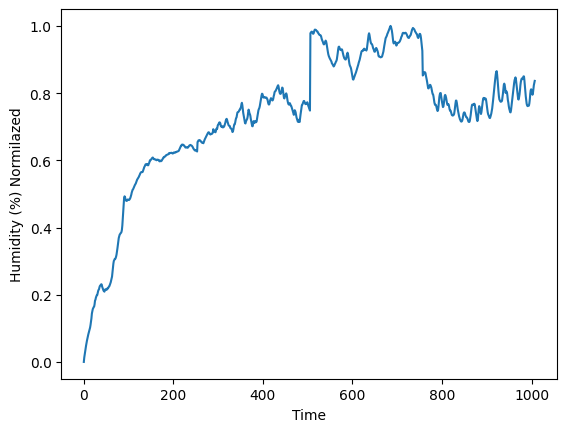

In [10]:
plt.plot(X)
plt.xlabel("Time")
plt.ylabel("Humidity (%) Normilazed")
plt.show()

In [11]:
### Prepare the data for RNN ###
def create_dataset(X, time_step=3):
    Xs = []
    ys = []
    for i in range(len(X) - time_step - 1):
        Xs.append(X[i:(i + time_step)])
        ys.append(X[i + time_step])
    return np.array(Xs), np.array(ys)


In [12]:
X_data, y_data = create_dataset(X, time_step=3)
X_data.shape, y_data.shape

((1004, 3), (1004,))

In [13]:
### split tha data into train and test ###
train_size = int(len(X_data) * 0.8)
test_size = len(X_data) - train_size
X_train, X_test = X_data[0:train_size], X_data[train_size:len(X_data)]
y_train, y_test = y_data[0:train_size], y_data[train_size:len(y_data)]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((803, 3), (201, 3), (803,), (201,))

## **One sample implementation**

In [14]:
sample_x = X_train[0]
sample_y = y_train[0]
print(sample_x, "->", sample_y)

[0.         0.01323155 0.02264631] -> 0.03231552162849871


In [15]:
import torch 
x_tensor = torch.tensor(sample_x).float()
y_tensor = torch.tensor(sample_y).float()

x_tensor, y_tensor

(tensor([0.0000, 0.0132, 0.0226]), tensor(0.0323))

In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [17]:
### Initialize params of LSTM cell ###
g = torch.Generator(42)
W_fx = torch.rand(1, generator=g, requires_grad=True, device=device)
W_fh = torch.rand(1, generator=g, requires_grad=True, device=device)
b_f = torch.zeros(1, requires_grad=True, device=device)
W_ix = torch.rand(1, generator=g, requires_grad=True, device=device)
W_ih = torch.rand(1, generator=g, requires_grad=True, device=device)
b_i = torch.zeros(1, requires_grad=True, device=device)
W_gx = torch.rand(1, generator=g, requires_grad=True, device=device)
W_gh = torch.rand(1, generator=g, requires_grad=True, device=device)
b_g = torch.zeros(1, requires_grad=True, device=device)
W_ox = torch.rand(1, generator=g, requires_grad=True, device=device)
W_oh = torch.rand(1, generator=g, requires_grad=True, device=device)
b_o = torch.zeros(1, requires_grad=True, device=device)
W_y = torch.rand(1, generator=g, requires_grad=True, device=device)
b_y = torch.zeros(1, requires_grad=True, device=device)

In [18]:
### feed forward ###
h_0 = torch.zeros(1, device=device)
c_0 = torch.zeros(1, device=device)
x_tensor = x_tensor.to(device)
y_tensor = y_tensor.to(device)

### t = 1 ###
### forget gate ###
z_f1 = W_fx * x_tensor[0] + W_fh * h_0 + b_f
f_1 = torch.sigmoid(z_f1)
### inputa gate ###
z_i1 = W_ix * x_tensor[0] + W_ih * h_0 + b_i
i_1 = torch.sigmoid(z_i1)
### candidate gate ###
z_g1 = W_gx * x_tensor[0] + W_gh * h_0 + b_g
g_1 = torch.tanh(z_g1)
### output gate ###
z_o1 = W_ox * x_tensor[0] + W_oh * h_0 + b_o
o_1 = torch.sigmoid(z_o1)
### Cell state ###
c_1 = f_1 * c_0 + i_1 * g_1
### Hidden state ###
h_1 = o_1 * torch.tanh(c_1)

### t = 2 ###
### forget gate ###
z_f2 = W_fx * x_tensor[1] + W_fh * h_1 + b_f
f_2 = torch.sigmoid(z_f2)
### inputa gate ###
z_i2 = W_ix * x_tensor[1] + W_ih * h_1 + b_i
i_2 = torch.sigmoid(z_i2)
### candidate gate ###
z_g2 = W_gx * x_tensor[1] + W_gh * h_1 + b_g
g_2 = torch.tanh(z_g2)
### output gate ###
z_o2 = W_ox * x_tensor[1] + W_oh * h_1 + b_o
o_2 = torch.sigmoid(z_o2)
### Cell state ###
c_2 = f_2 * c_1 + i_2 * g_2
### Hidden state ###
h_2 = o_2 * torch.tanh(c_2)

### t = 3 ###
### forget gate ###
z_f3 = W_fx * x_tensor[2] + W_fh * h_2 + b_f
f_3 = torch.sigmoid(z_f3)
### inputa gate ###
z_i3 = W_ix * x_tensor[2] + W_ih * h_2 + b_i
i_3 = torch.sigmoid(z_i3)
### candidate gate ###
z_g3 = W_gx * x_tensor[2] + W_gh * h_2 + b_g
g_3 = torch.tanh(z_g3)
### output gate ###
z_o3 = W_ox * x_tensor[2] + W_oh * h_2 + b_o
o_3 = torch.sigmoid(z_o3)
### Cell state ###
c_3 = f_3 * c_2 + i_3 * g_3
### Hidden state ###
h_3 = o_3 * torch.tanh(c_3)

y_pred = W_y * h_3 + b_y
print("Predicted:", y_pred, "Actual:", y_tensor)

Predicted: tensor([0.0014], device='mps:0', grad_fn=<AddBackward0>) Actual: tensor(0.0323, device='mps:0')


In [19]:
### Calculating Loss ###
### MSE ###
loss = 0.5 * ((y_pred - y_tensor) ** 2)
print("Loss:", loss*10000)

Loss: tensor([4.7888], device='mps:0', grad_fn=<MulBackward0>)


In [20]:
### Backpropogation ###
# gradients
loss.backward()
dL_d_wy = W_y.grad
dL_d_by = b_y.grad
dL_d_W_fx = W_fx.grad
dL_d_W_fh = W_fh.grad
dL_d_bf = b_f.grad
dL_d_W_ix = W_ix.grad
dL_d_W_ih = W_ih.grad
dL_d_bi = b_i.grad
dL_d_W_gx = W_gx.grad
dL_d_W_gh = W_gh.grad
dL_d_bg = b_g.grad
dL_d_W_ox = W_ox.grad
dL_d_W_oh = W_oh.grad
dL_d_bo = b_o.grad 


In [21]:
### Upfdate parameters ###
lr = 0.1
with torch.no_grad():
    W_y -= lr * dL_d_wy
    b_y -= lr * dL_d_by
    W_fx -= lr * dL_d_W_fx
    W_fh -= lr * dL_d_W_fh
    b_f -= lr * dL_d_bf
    W_ix -= lr * dL_d_W_ix
    W_ih -= lr * dL_d_W_ih
    b_i -= lr * dL_d_bi
    W_gx -= lr * dL_d_W_gx
    W_gh -= lr * dL_d_W_gh
    b_g -= lr * dL_d_bg
    W_ox -= lr * dL_d_W_ox
    W_oh -= lr * dL_d_W_oh
    b_o -= lr * dL_d_bo

In [22]:
### feed forward ###
h_0 = torch.zeros(1, device=device)
c_0 = torch.zeros(1, device=device)

### t = 1 ###
### forget gate ###
z_f1 = W_fx * x_tensor[0] + W_fh * h_0 + b_f
f_1 = torch.sigmoid(z_f1)
### inputa gate ###
z_i1 = W_ix * x_tensor[0] + W_ih * h_0 + b_i
i_1 = torch.sigmoid(z_i1)
### candidate gate ###
z_g1 = W_gx * x_tensor[0] + W_gh * h_0 + b_g
g_1 = torch.sigmoid(z_g1)
### output gate ###
z_o1 = W_ox * x_tensor[0] + W_oh * h_0 + b_o
o_1 = torch.sigmoid(z_o1)
### Cell state ###
c_1 = f_1 * c_0 + i_1 * g_1
### Hidden state ###
h_1 = o_1 * torch.tanh(c_1)

### t = 2 ###
### forget gate ###
z_f2 = W_fx * x_tensor[1] + W_fh * h_1 + b_f
f_2 = torch.sigmoid(z_f2)
### inputa gate ###
z_i2 = W_ix * x_tensor[1] + W_ih * h_1 + b_i
i_2 = torch.sigmoid(z_i2)
### candidate gate ###
z_g2 = W_gx * x_tensor[1] + W_gh * h_1 + b_g
g_2 = torch.sigmoid(z_g2)
### output gate ###
z_o2 = W_ox * x_tensor[1] + W_oh * h_1 + b_o
o_2 = torch.sigmoid(z_o2)
### Cell state ###
c_2 = f_2 * c_1 + i_2 * g_2
### Hidden state ###
h_2 = o_2 * torch.tanh(c_2)

### t = 3 ###
### forget gate ###
z_f3 = W_fx * x_tensor[2] + W_fh * h_2 + b_f
f_3 = torch.sigmoid(z_f3)
### inputa gate ###
z_i3 = W_ix * x_tensor[2] + W_ih * h_2 + b_i
i_3 = torch.sigmoid(z_i3)
### candidate gate ###
z_g3 = W_gx * x_tensor[2] + W_gh * h_2 + b_g
g_3 = torch.sigmoid(z_g3)
### output gate ###
z_o3 = W_ox * x_tensor[2] + W_oh * h_2 + b_o
o_3 = torch.sigmoid(z_o3)
### Cell state ###
c_3 = f_3 * c_2 + i_3 * g_3
### Hidden state ###
h_3 = o_3 * torch.tanh(c_3)

y_pred = W_y * h_3 + b_y
print("Predicted:", y_pred, "Actual:", y_tensor)

Predicted: tensor([0.0569], device='mps:0', grad_fn=<AddBackward0>) Actual: tensor(0.0323, device='mps:0')


In [23]:
### Calculating Loss ###
### MSE ###
loss = 0.5 * ((y_pred - y_tensor) ** 2)
print("Loss:", loss*10000)

Loss: tensor([3.0223], device='mps:0', grad_fn=<MulBackward0>)


In [24]:
### Backpropogation ###
# gradients
loss.backward()
dL_d_wy = W_y.grad
dL_d_by = b_y.grad
dL_d_W_fx = W_fx.grad
dL_d_W_fh = W_fh.grad
dL_d_bf = b_f.grad
dL_d_W_ix = W_ix.grad
dL_d_W_ih = W_ih.grad
dL_d_bi = b_i.grad
dL_d_W_gx = W_gx.grad
dL_d_W_gh = W_gh.grad
dL_d_bg = b_g.grad
dL_d_W_ox = W_ox.grad
dL_d_W_oh = W_oh.grad
dL_d_bo = b_o.grad 


In [25]:
### Upfdate parameters ###
lr = 0.1
with torch.no_grad():
    W_y -= lr * dL_d_wy
    b_y -= lr * dL_d_by
    W_fx -= lr * dL_d_W_fx
    W_fh -= lr * dL_d_W_fh
    b_f -= lr * dL_d_bf
    W_ix -= lr * dL_d_W_ix
    W_ih -= lr * dL_d_W_ih
    b_i -= lr * dL_d_bi
    W_gx -= lr * dL_d_W_gx
    W_gh -= lr * dL_d_W_gh
    b_g -= lr * dL_d_bg
    W_ox -= lr * dL_d_W_ox
    W_oh -= lr * dL_d_W_oh
    b_o -= lr * dL_d_bo

In [26]:
### feed forward ###
h_0 = torch.zeros(1, device=device)
c_0 = torch.zeros(1, device=device)

### t = 1 ###
### forget gate ###
z_f1 = W_fx * x_tensor[0] + W_fh * h_0 + b_f
f_1 = torch.sigmoid(z_f1)
### inputa gate ###
z_i1 = W_ix * x_tensor[0] + W_ih * h_0 + b_i
i_1 = torch.sigmoid(z_i1)
### candidate gate ###
z_g1 = W_gx * x_tensor[0] + W_gh * h_0 + b_g
g_1 = torch.sigmoid(z_g1)
### output gate ###
z_o1 = W_ox * x_tensor[0] + W_oh * h_0 + b_o
o_1 = torch.sigmoid(z_o1)
### Cell state ###
c_1 = f_1 * c_0 + i_1 * g_1
### Hidden state ###
h_1 = o_1 * torch.tanh(c_1)

### t = 2 ###
### forget gate ###
z_f2 = W_fx * x_tensor[1] + W_fh * h_1 + b_f
f_2 = torch.sigmoid(z_f2)
### inputa gate ###
z_i2 = W_ix * x_tensor[1] + W_ih * h_1 + b_i
i_2 = torch.sigmoid(z_i2)
### candidate gate ###
z_g2 = W_gx * x_tensor[1] + W_gh * h_1 + b_g
g_2 = torch.sigmoid(z_g2)
### output gate ###
z_o2 = W_ox * x_tensor[1] + W_oh * h_1 + b_o
o_2 = torch.sigmoid(z_o2)
### Cell state ###
c_2 = f_2 * c_1 + i_2 * g_2
### Hidden state ###
h_2 = o_2 * torch.tanh(c_2)

### t = 3 ###
### forget gate ###
z_f3 = W_fx * x_tensor[2] + W_fh * h_2 + b_f
f_3 = torch.sigmoid(z_f3)
### inputa gate ###
z_i3 = W_ix * x_tensor[2] + W_ih * h_2 + b_i
i_3 = torch.sigmoid(z_i3)
### candidate gate ###
z_g3 = W_gx * x_tensor[2] + W_gh * h_2 + b_g
g_3 = torch.sigmoid(z_g3)
### output gate ###
z_o3 = W_ox * x_tensor[2] + W_oh * h_2 + b_o
o_3 = torch.sigmoid(z_o3)
### Cell state ###
c_3 = f_3 * c_2 + i_3 * g_3
### Hidden state ###
h_3 = o_3 * torch.tanh(c_3)

y_pred = W_y * h_3 + b_y
print("Predicted:", y_pred, "Actual:", y_tensor)

Predicted: tensor([0.0574], device='mps:0', grad_fn=<AddBackward0>) Actual: tensor(0.0323, device='mps:0')


In [27]:
### Calculating Loss ###
### MSE ###
loss = 0.5 * ((y_pred - y_tensor) ** 2)
print("Loss:", loss*10000)

Loss: tensor([3.1427], device='mps:0', grad_fn=<MulBackward0>)


## **Putting all together**

In [28]:
import torch
X_train_tensor = torch.tensor(X_train).float().to(device)
y_train_tensor = torch.tensor(y_train).float().to(device)
X_test_tensor = torch.tensor(X_test).float().to(device)
y_test_tensor = torch.tensor(y_test).float().to(device)

In [29]:
X_train_tensor[0]

tensor([0.0000, 0.0132, 0.0226], device='mps:0')

In [30]:
### Initialize params of LSTM cell ###
g = torch.Generator(42)
W_fx = torch.rand(1, generator=g, requires_grad=True, device=device)
W_fh = torch.rand(1, generator=g, requires_grad=True, device=device)
b_f = torch.zeros(1, requires_grad=True, device=device)
W_ix = torch.rand(1, generator=g, requires_grad=True, device=device)
W_ih = torch.rand(1, generator=g, requires_grad=True, device=device)
b_i = torch.zeros(1, requires_grad=True, device=device)
W_gx = torch.rand(1, generator=g, requires_grad=True, device=device)
W_gh = torch.rand(1, generator=g, requires_grad=True, device=device)
b_g = torch.zeros(1, requires_grad=True, device=device)
W_ox = torch.rand(1, generator=g, requires_grad=True, device=device)
W_oh = torch.rand(1, generator=g, requires_grad=True, device=device)
b_o = torch.zeros(1, requires_grad=True, device=device)
W_y = torch.rand(1, generator=g, requires_grad=True, device=device)
b_y = torch.zeros(1, requires_grad=True, device=device)

In [31]:
### Initialize params of LSTM cell ###

epoches = 100
losses = []
lr = 0.001

params = [W_fx, W_fh, b_f,
          W_ix, W_ih, b_i,
          W_gx, W_gh, b_g,
          W_ox, W_oh, b_o,
          W_y, b_y]

for epoch in range(epoches):
    total_loss = 0.0  # Python float accumulator

    # (optional) reinitialize h_0/c_0 here or inside loop per sample
    # h_0 = torch.zeros(1, device=device)
    # c_0 = torch.zeros(1, device=device)

    for i in range(len(X_train_tensor)):
        x_tensor = X_train_tensor[i]
        sample_y = y_train_tensor[i]

        # reset per-sample initial states
        h_0 = torch.zeros(1, device=device)
        c_0 = torch.zeros(1, device=device)

        # ---------------------------
        # Clear previous gradients
        # ---------------------------
        for p in params:
            p.grad = None

        # Feed forward
        ### t = 1 ###
        z_f1 = W_fx * x_tensor[0] + W_fh * h_0 + b_f
        f_1 = torch.sigmoid(z_f1)
        z_i1 = W_ix * x_tensor[0] + W_ih * h_0 + b_i
        i_1 = torch.sigmoid(z_i1)
        z_g1 = W_gx * x_tensor[0] + W_gh * h_0 + b_g
        g_1 = torch.tanh(z_g1)
        z_o1 = W_ox * x_tensor[0] + W_oh * h_0 + b_o
        o_1 = torch.sigmoid(z_o1)
        c_1 = f_1 * c_0 + i_1 * g_1
        h_1 = o_1 * torch.tanh(c_1)

        ### t = 2 ###
        z_f2 = W_fx * x_tensor[1] + W_fh * h_1 + b_f
        f_2 = torch.sigmoid(z_f2)
        z_i2 = W_ix * x_tensor[1] + W_ih * h_1 + b_i
        i_2 = torch.sigmoid(z_i2)
        z_g2 = W_gx * x_tensor[1] + W_gh * h_1 + b_g
        g_2 = torch.tanh(z_g2)
        z_o2 = W_ox * x_tensor[1] + W_oh * h_1 + b_o
        o_2 = torch.sigmoid(z_o2)
        c_2 = f_2 * c_1 + i_2 * g_2
        h_2 = o_2 * torch.tanh(c_2)

        ### t = 3 ###
        z_f3 = W_fx * x_tensor[2] + W_fh * h_2 + b_f
        f_3 = torch.sigmoid(z_f3)
        z_i3 = W_ix * x_tensor[2] + W_ih * h_2 + b_i
        i_3 = torch.sigmoid(z_i3)
        z_g3 = W_gx * x_tensor[2] + W_gh * h_2 + b_g
        g_3 = torch.tanh(z_g3)
        z_o3 = W_ox * x_tensor[2] + W_oh * h_2 + b_o
        o_3 = torch.sigmoid(z_o3)
        c_3 = f_3 * c_2 + i_3 * g_3
        h_3 = o_3 * torch.tanh(c_3)

        y_pred = W_y * h_3 + b_y

        # Calculate loss (scalar tensor)
        loss = 0.5 * ((y_pred - sample_y) ** 2)

        # Accumulate numeric loss
        total_loss += loss.item()

        # Backpropagation
        loss.backward()

        # Update parameters safely (no_grad + .data)
        with torch.no_grad():
            for p in params:
                if p.grad is not None:
                    p.data -= lr * p.grad

    avg_loss = total_loss / len(X_train_tensor)
    losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss}")


Epoch 0, Loss: 0.10101647763918235
Epoch 10, Loss: 0.010890299076318952
Epoch 20, Loss: 0.007112594492483201
Epoch 30, Loss: 0.0040421932267996185
Epoch 40, Loss: 0.002081596509695747
Epoch 50, Loss: 0.0010514558403712884
Epoch 60, Loss: 0.0005832563784290158
Epoch 70, Loss: 0.0003897738869107509
Epoch 80, Loss: 0.00031331098494956464
Epoch 90, Loss: 0.000282836839936506


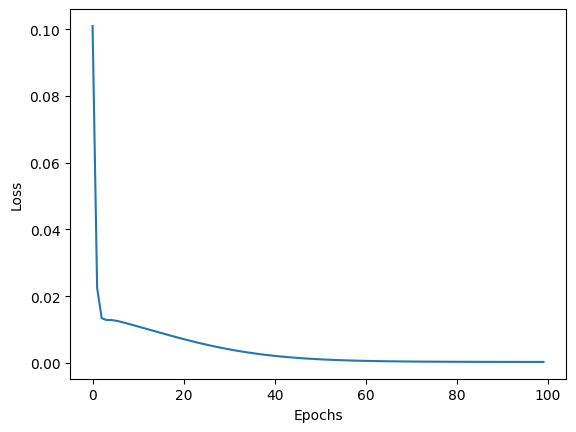

In [32]:
loss = torch.tensor(losses).cpu()
plt.plot(loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [33]:
predictions = []
for i in range(len(X_test_tensor)):
    x_tensor = X_test_tensor[i]

    # Feed forward
    ### t = 1 ###
    z_f1 = W_fx * x_tensor[0] + W_fh * h_0 + b_f
    f_1 = torch.sigmoid(z_f1)
    z_i1 = W_ix * x_tensor[0] + W_ih * h_0 + b_i
    i_1 = torch.sigmoid(z_i1)
    z_g1 = W_gx * x_tensor[0] + W_gh * h_0 + b_g
    g_1 = torch.tanh(z_g1)
    z_o1 = W_ox * x_tensor[0] + W_oh * h_0 + b_o
    o_1 = torch.sigmoid(z_o1)
    c_1 = f_1 * c_0 + i_1 * g_1
    h_1 = o_1 * torch.tanh(c_1)

    ### t = 2 ###
    z_f2 = W_fx * x_tensor[1] + W_fh * h_1 + b_f
    f_2 = torch.sigmoid(z_f2)
    z_i2 = W_ix * x_tensor[1] + W_ih * h_1 + b_i
    i_2 = torch.sigmoid(z_i2)
    z_g2 = W_gx * x_tensor[1] + W_gh * h_1 + b_g
    g_2 = torch.tanh(z_g2)
    z_o2 = W_ox * x_tensor[1] + W_oh * h_1 + b_o
    o_2 = torch.sigmoid(z_o2)
    c_2 = f_2 * c_1 + i_2 * g_2
    h_2 = o_2 * torch.tanh(c_2)

    ### t = 3 ###
    z_f3 = W_fx * x_tensor[2] + W_fh * h_2 + b_f
    f_3 = torch.sigmoid(z_f3)
    z_i3 = W_ix * x_tensor[2] + W_ih * h_2 + b_i
    i_3 = torch.sigmoid(z_i3)
    z_g3 = W_gx * x_tensor[2] + W_gh * h_2 + b_g
    g_3 = torch.tanh(z_g3)
    z_o3 = W_ox * x_tensor[2] + W_oh * h_2 + b_o
    o_3 = torch.sigmoid(z_o3)
    c_3 = f_3 * c_2 + i_3 * g_3
    h_3 = o_3 * torch.tanh(c_3)

    y_pred = W_y * h_3 + b_y

    predictions.append(y_pred)
predictions = torch.tensor(predictions).cpu()

/var/folders/wn/mbrtzszd0kzcw3kh3j7xymyh0000gn/T/ipykernel_66480/2241516161.py:45: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  predictions = torch.tensor(predictions).cpu()


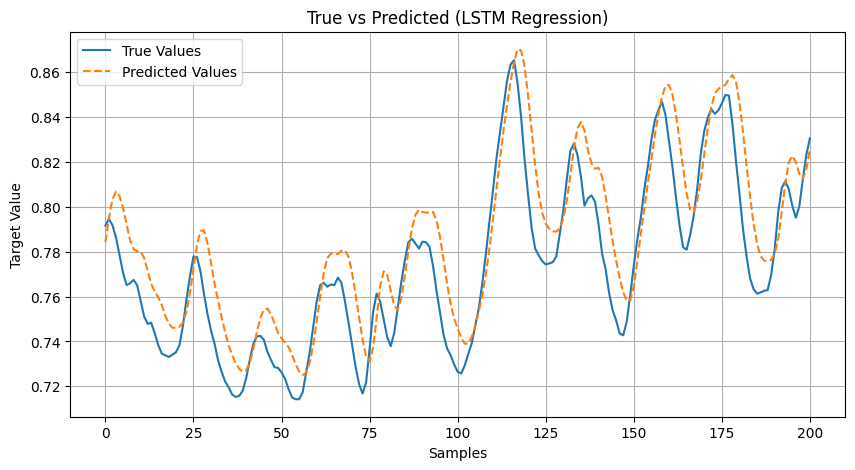

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test, label="True Values")
plt.plot(predictions, label="Predicted Values", linestyle='--')
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.title("True vs Predicted (LSTM Regression)")
plt.legend()
plt.grid(True)
plt.show()


## **LSTM with PyTorch**

In [81]:
X_train_tensor = torch.tensor(X_train).float().to(device)
y_train_tensor = torch.tensor(y_train).float().to(device)
X_test_tensor = torch.tensor(X_test).float().to(device)
y_test_tensor = torch.tensor(y_test).float().to(device)

In [82]:
X_train_tensor.shape

torch.Size([803, 3])

In [83]:
y_train_tensor.shape

torch.Size([803])

In [84]:
X_train_tensor = X_train_tensor.reshape(-1, 3, 1)
X_test_tensor = X_test_tensor.reshape(-1, 3, 1)
# X_train_tensor = X_train_tensor.unsqueeze(-1)
X_train_tensor.shape

torch.Size([803, 3, 1])

In [88]:
### Building LSTM with PyTorch ###
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=1, num_layers=1)
        self.lstm2 = nn.LSTM(input_size=1, hidden_size=1, num_layers=1)
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out2, _ = self.lstm2(out)         
        out = self.fc(out2[:, -1, :]) 
        return out
    
class RNNModel(nn.Module):
    def __init__(self):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=1, num_layers=1)
        self.fc = nn.Linear(1, 1)

    def forward(self, x):
        out, _ = self.rnn(x)         # output from all time steps
        out = self.fc(out[:, -1, :]) # take last time step
        return out

model = LSTMModel().to(device)
# model = RNNModel().to(device)

In [89]:
def param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("Trainable parameters:", param_count(model))

LSTMModel(
  (lstm1): LSTM(1, 1)
  (lstm2): LSTM(1, 1)
  (fc): Linear(in_features=1, out_features=1, bias=True)
)
Trainable parameters: 34


In [90]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 1000
losses = []

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    
    y_pred = model(X_train_tensor).squeeze()   
    loss = criterion(y_pred, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 0.9857
Epoch 10, Loss: 0.6461
Epoch 20, Loss: 0.4264
Epoch 30, Loss: 0.2855
Epoch 40, Loss: 0.1956
Epoch 50, Loss: 0.1386
Epoch 60, Loss: 0.1026
Epoch 70, Loss: 0.0799
Epoch 80, Loss: 0.0656
Epoch 90, Loss: 0.0566
Epoch 100, Loss: 0.0509
Epoch 110, Loss: 0.0474
Epoch 120, Loss: 0.0451
Epoch 130, Loss: 0.0436
Epoch 140, Loss: 0.0426
Epoch 150, Loss: 0.0420
Epoch 160, Loss: 0.0415
Epoch 170, Loss: 0.0411
Epoch 180, Loss: 0.0409
Epoch 190, Loss: 0.0406
Epoch 200, Loss: 0.0404
Epoch 210, Loss: 0.0402
Epoch 220, Loss: 0.0400
Epoch 230, Loss: 0.0398
Epoch 240, Loss: 0.0396
Epoch 250, Loss: 0.0394
Epoch 260, Loss: 0.0392
Epoch 270, Loss: 0.0390
Epoch 280, Loss: 0.0388
Epoch 290, Loss: 0.0386
Epoch 300, Loss: 0.0384
Epoch 310, Loss: 0.0382
Epoch 320, Loss: 0.0380
Epoch 330, Loss: 0.0378
Epoch 340, Loss: 0.0376
Epoch 350, Loss: 0.0374
Epoch 360, Loss: 0.0371
Epoch 370, Loss: 0.0369
Epoch 380, Loss: 0.0367
Epoch 390, Loss: 0.0364
Epoch 400, Loss: 0.0362
Epoch 410, Loss: 0.0360
Epo

In [91]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_tensor).squeeze().cpu().numpy()


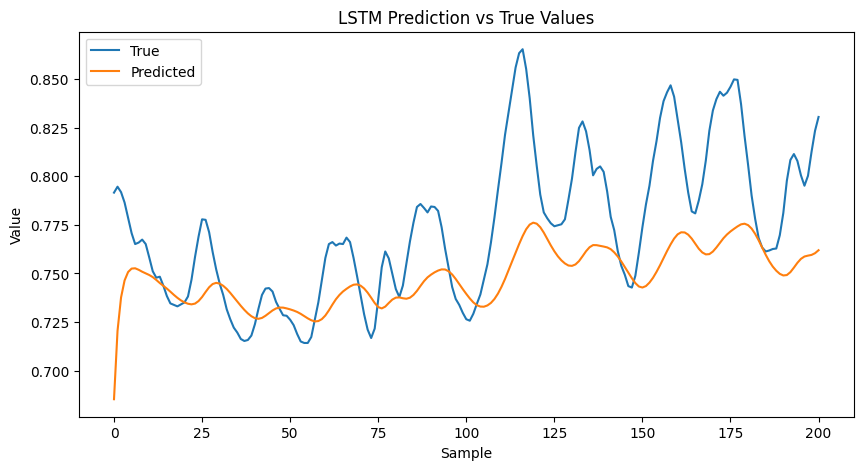

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test, label="True")
plt.plot(y_test_pred, label="Predicted")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Value")
plt.title("LSTM Prediction vs True Values")
plt.show()


## **Multi-Cell RNN and LSTM**

In [ ]:
X_train_tensor = torch.tensor(X_train).float().to(device)
y_train_tensor = torch.tensor(y_train).float().to(device)
X_test_tensor = torch.tensor(X_test).float().to(device)
y_test_tensor = torch.tensor(y_test).float().to(device)

X_train_tensor = X_train_tensor.reshape(-1, X_train_tensor.shape[1], 1)
X_test_tensor = X_test_tensor.reshape(-1, X_train_tensor.shape[1], 1)
# X_train_tensor = X_train_tensor.unsqueeze(-1)
X_train_tensor.shape

In [ ]:

### Building LSTM with PyTorch ###
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=5, num_layers=1, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=1, hidden_size=5, num_layers=1, batch_first=True)
        self.fc = nn.Linear(5, 1)

    def forward(self, x):
        out, _ = self.lstm(x)         
        out = self.fc(out[:, -1, :]) 
        return out
    
class RNNModel(nn.Module):
    def __init__(self):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=5, num_layers=1, batch_first=True)
        self.fc = nn.Linear(5, 1)

    def forward(self, x):
        out, _ = self.rnn(x)         # output from all time steps
        out = self.fc(out[:, -1, :]) # take last time step
        return out

# model = LSTMModel().to(device)
model = RNNModel().to(device)


In [ ]:
def param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("Trainable parameters:", param_count(model))

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 1000
losses = []

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    
    y_pred = model(X_train_tensor).squeeze()   
    loss = criterion(y_pred, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


In [ ]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_tensor).squeeze().cpu().numpy()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test, label="True")
plt.plot(y_test_pred, label="Predicted")
plt.legend()
plt.xlabel("Sample")
plt.ylabel("Value")
plt.title("LSTM Prediction vs True Values")
plt.show()
